# **resum of the content of txt transformer en csv (columns)**




- Colonnes communes aux deux CSV:
  - **id** : Le numéro d'ordre de la phrase dans le fichier texte original. Permet d'identifier et de retrouver chaque phrase facilement.
  - **sentence** : Le texte brut de la phrase (ou du groupe de phrases) extrait du fichier. C'est le contenu du tweet ou de l'énoncé analysé.
  - **has_emotion** : Indique si au moins une émotion a été détectée dans la phrase (1) ou pas (0). C'est le flag général de présence d'émotion.label : Issu du fichier corpus_haineux.csv, il indique si le tweet est haineux (1) ou non haineux (0). C'est la variable cible pour un éventuel modèle de classification.

- Colonnes spécifiques à emotions_features (**1er CSV(emotions)**) :
  - **tokens** : Les mots exacts du texte (tels qu'ils apparaissent) qui portent une émotion, par exemple aime, révolte. C'est la forme brute telle qu'elle est dans la phrase.
  - **lemmas** : La forme canonique (infinitif ou base) des tokens émotionnels, par exemple aimer, révolter. Le lemme permet de regrouper les variantes d'un même mot.
  - **categories** : La ou les catégories d'émotion associées aux lemmes, par exemple amour, colere, mepris, empathie. Plusieurs catégories peuvent coexister dans une même phrase, séparées par une virgule.


- Colonnes spécifiques à emotyc (**2ème CSV(emotyc**) :
  - **avec_emo** : Flag global indiquant qu'une émotion quelconque a été détectée dans la phrase (1/0). C'est l'équivalent de has_emotion, mais issu directement du système d'annotation EMOTYC.
  - **avec_emo_montree** : L'émotion est exprimée de façon explicite et directe par le locuteur, par exemple via une interjection ou une exclamation. Le locuteur manifeste clairement son état émotionnel.
  - **avec_emo_designee** : L'émotion est nommée explicitement dans le texte, par exemple "je suis en colère". Le mot désignant l'émotion est présent tel quel dans la phrase.
  - **avec_emo_suggeree** : L'émotion n'est pas nommée mais est sous-entendue par le contexte ou le contenu du message. Elle se déduit sans que le locuteur ne l'exprime directement.
  - **avec_emo_comportementale** : L'émotion transparaît à travers un comportement décrit ou évoqué, par exemple une action qui trahit un sentiment. Ce type renvoie à ce que le locuteur fait plutôt qu'à ce qu'il ressent.
  - **avec_emo_complexe** : La phrase contient une émotion dite "complexe", c'est-à-dire mêlant plusieurs états affectifs ou difficile à réduire à une seule catégorie de base. C'est souvent une combinaison d'émotions primaires.
  - **avec_emo_base** : L'émotion appartient aux émotions dites "de base" ou primaires (joie, peur, colère, tristesse, surprise, dégoût). Ces émotions sont universelles et reconnues comme fondamentales en psychologie des émotions.
  - **avec_cat_colere** : La phrase exprime de la colère, comme de l'indignation, de l'hostilité ou de la rage. C'est une des catégories émotionnelles les plus fréquentes dans un corpus de discours haineux.
  - **avec_cat_peur** : La phrase véhicule une émotion de peur, d'inquiétude ou d'angoisse. Elle peut être exprimée par le locuteur lui-même ou projetée sur une situation décrite.
  - **avec_cat_joie** : La phrase exprime un sentiment positif comme le bonheur, le plaisir ou la satisfaction. Elle est plus rare dans un corpus haineux mais peut apparaître dans des contextes ironiques.
  - **avec_cat_tristesse** : La phrase contient une émotion de tristesse, de déception ou de mélancolie. Elle peut indiquer un sentiment de perte ou d'impuissance face à une situation.
  - **avec_cat_surprise** : La phrase exprime de l'étonnement ou de la stupéfaction, positif ou négatif. Elle se manifeste souvent via des signes typographiques comme !!! ou des termes comme "hallucinant".
  - **avec_cat_admiration** : La phrase contient une émotion d'admiration ou d'appréciation envers quelqu'un ou quelque chose. Attention : dans ce corpus, cette catégorie peut aussi capturer des cas d'amour ou d'attachement (comme j'aime).
  - **avec_cat_autre** : La phrase porte une émotion qui ne rentre dans aucune des catégories définies ci-dessus. C'est un fourre-tout pour les cas ambigus ou atypiques du système d'annotation.
  - **avec_cat_fierte** : la phrase exprime de la fierté, un sentiment de satisfaction par rapport à quelque chose ou quelqu'un.
  - **avec_cat_embarras** : la phrase exprime de l'embarras ou de la gêne, une émotion sociale souvent liée à une situation inconfortable.

# **1. haineux_emotion**

## 1.1 Conversion emotions_features.txt → CSV (pour le decouvrir)
Ce notebook parse le fichier texte et crée un CSV avec les colonnes :
- `id` : numéro de la phrase
- `sentence` : texte de la phrase
- `has_emotion` : True/False
- `tokens` : tokens ayant une émotion
- `lemmas` : lemmes ayant une émotion
- `categories` : catégories d'émotion

In [36]:
# Étape 1 : Upload du fichier
from google.colab import files
uploaded = files.upload()  # Sélectionner emotions_features.txt

Saving emotions_features.txt to emotions_features (1).txt


In [37]:
import re
import csv
import pandas as pd

# Lire le fichier uploadé
filename = list(uploaded.keys())[0]
with open(filename, 'r', encoding='utf-8') as f:
    content = f.read()

print(f"Fichier chargé : {filename}")
print(f"Taille : {len(content)} caractères")

Fichier chargé : emotions_features (1).txt
Taille : 140571 caractères


In [38]:
def parse_emotions_file(content):
    """
    Parse le fichier emotions_features.txt.
    Chaque bloc est délimité par un numéro suivi de 'Sentence:'.
    """
    records = []

    # Découper en blocs par entrée numérotée
    # Pattern : début d'un bloc = ligne commençant par un chiffre suivi d'un point
    pattern = re.compile(
        r'^(\d+)\.\s+Sentence:\s*(.+?)(?=^\d+\.\s+Sentence:|\Z)',
        re.MULTILINE | re.DOTALL
    )

    matches = pattern.findall(content)

    for match in matches:
        entry_id = int(match[0])
        block = match[1].strip()

        # Extraire le texte de la phrase (lignes avant les features)
        lines = block.split('\n')
        sentence_lines = []
        feature_start = None

        for i, line in enumerate(lines):
            if (line.strip().startswith('No features found.') or
                line.strip().startswith('Tokens having emotion:') or
                line.strip().startswith('Lemmas having emotion:') or
                line.strip().startswith('Categories of the emotion lemmas:')):
                feature_start = i
                break
            sentence_lines.append(line)

        sentence = ' '.join(l.strip() for l in sentence_lines if l.strip())

        # Extraire les features
        tokens = None
        lemmas = None
        categories = None
        has_emotion = False

        feature_text = block if feature_start is None else '\n'.join(lines[feature_start:])

        tok_match = re.search(r'Tokens having emotion:\s*\[\s*(.+?)\s*\]', feature_text)
        lem_match = re.search(r'Lemmas having emotion:\s*\[\s*(.+?)\s*\]', feature_text)
        cat_match = re.search(r'Categories of the emotion lemmas:\s*\[\s*(.+?)\s*\]', feature_text)

        if tok_match:
            tokens = tok_match.group(1).strip()
            has_emotion = True
        if lem_match:
            lemmas = lem_match.group(1).strip()
        if cat_match:
            categories = cat_match.group(1).strip()

        records.append({
            'id': entry_id,
            'sentence': sentence,
            'has_emotion': has_emotion,
            'tokens': tokens,
            'lemmas': lemmas,
            'categories': categories
        })

    return records

records = parse_emotions_file(content)
print(f"Nombre d'entrées parsées : {len(records)}")

Nombre d'entrées parsées : 796


In [39]:
# Créer le DataFrame
df = pd.DataFrame(records)

print(f"Shape : {df.shape}")
print(f"Entrées AVEC émotion  : {df['has_emotion'].sum()}")
print(f"Entrées SANS émotion  : {(~df['has_emotion']).sum()}")
print()
df.head(10)

Shape : (796, 6)
Entrées AVEC émotion  : 170
Entrées SANS émotion  : 626



,id,sentence,has_emotion,tokens,lemmas,categories
0,1,Tous ces migrants qui envahissent nos hôpitaux!!!,False,None,None,None
1,2,Manquerait plus que la république tchèque prop...,False,None,None,None
2,3,https://t.co/7H7Rs0CkGJ,False,None,None,None
3,4,Les #migrants #maghrebins qui envahissent la🇫🇷...,True,sensible,sensible,non_specifiee
4,5,"oui, mais y'a soros (ami de macron, soit dit e...",True,ami,ami,amour
5,6,En plein délire parce que 3 migrants ont fabri...,False,None,None,None
6,7,@ZKongkin @MadjidFalastine @GILLESLEMAU,False,None,None,None
7,8,"Les migrants envahissent la France, c’est un f...",True,bafouant,bafouer,mepris
8,9,Le dire et dénoncer les effets collatéraux don...,False,None,None,None
9,10,Les mots ont un sens @Ombrelumire2 @IsabelleCh...,False,None,None,None


In [40]:
# Aperçu des entrées avec émotion
df[df['has_emotion']].head(10)

,id,sentence,has_emotion,tokens,lemmas,categories
3,4,Les #migrants #maghrebins qui envahissent la🇫🇷...,True,sensible,sensible,non_specifiee
4,5,"oui, mais y'a soros (ami de macron, soit dit e...",True,ami,ami,amour
7,8,"Les migrants envahissent la France, c’est un f...",True,bafouant,bafouer,mepris
14,15,J'aime les arbres.,True,aime,aimer,amour
16,17,J'aime la France.,True,aime,aimer,amour
20,21,@Dimitri_R C est super joli !!! 😍 😍 😍 Putain y...,True,"critiquer, compatis","critiquer, compatir","mepris, empathie"
22,23,"Sans masques ni tests, ces connards qui disent...",True,révolte,révolter,colere
35,36,Mais ces temps ci j'ai quand même une sacrée c...,True,colère,colère,colere
42,43,Comme me l’a dit l’héroïque vendeuse de ma sup...,True,intérêt,intérêt,desir
47,48,Faut revoir les traditions https://t.co/TuoDDj...,True,critiquer,critiquer,mepris


In [41]:
df['has_emotion_bool'] = df['has_emotion'].astype(int)

print(df[['id', 'has_emotion', 'has_emotion_bool']].head(10))

   id  has_emotion  has_emotion_bool
0   1        False                 0
1   2        False                 0
2   3        False                 0
3   4         True                 1
4   5         True                 1
5   6        False                 0
6   7        False                 0
7   8         True                 1
8   9        False                 0
9  10        False                 0


In [32]:
# Distribution de la feature 'has_emotion_bool'
print("Distribution de 'has_emotion_bool' :")
print(df['has_emotion_bool'].value_counts())

Distribution de 'has_emotion_bool' :


KeyError: 'has_emotion_bool'

In [43]:
# Distribution des catégories d'émotion
df_emotions = df[df['categories'].notna()].copy()

# Éclater les catégories multiples (ex: 'mepris, empathie')
all_cats = df_emotions['categories'].str.split(',').explode().str.strip()
print("Distribution des catégories d'émotion :")
print(all_cats.value_counts())

Distribution des catégories d'émotion :
categories
amour            41
desir            29
ressentiment     24
non_specifiee    20
joie             19
peur             14
tristesse         9
admiration        8
mepris            7
apaisement        6
colere            5
surprise          5
comportement      5
culpabilite       4
inhumanite        4
embarras          3
empathie          2
audace            2
deplaisir         2
fierte            2
dégoût            1
Name: count, dtype: int64


In [44]:
# Exporter en CSV
output_filename = 'emotions_features.csv'
df.to_csv(output_filename, index=False, encoding='utf-8-sig')
print(f"CSV exporté : {output_filename}")

# Télécharger le fichier
files.download(output_filename)

CSV exporté : emotions_features.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 1.2 CAMAMBERT SANS FINE TUNING

In [6]:
!pip install -q transformers torch scikit-learn pandas numpy matplotlib seaborn

import torch
print("GPU disponible :", torch.cuda.is_available())
print("Device :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

import re
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from transformers import (
    CamembertTokenizer,
    CamembertModel,
)
from torch.optim import AdamW
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device utilisé : {DEVICE}")

GPU disponible : False
Device : CPU
Device utilisé : cpu


In [7]:
#importer les donnees
# impoter le csv generer par nassim ( il a fusionner le haineux emotion avec haineux_brut, pour avoir le label (haineux/non haineux))
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


Saving corpus_haine_emotion.csv to corpus_haine_emotion (1).csv
User uploaded file "corpus_haine_emotion (1).csv" with length 122790 bytes


In [8]:
df.head(5)

,tweet,label,Tokens,Lemmas,Cats,emotion_ids,emotion_list
0,Tous ces migrants qui envahissent nos hôpitaux...,1,[],[],[],"[np.int64(1), np.int64(2), np.int64(3)]",[]
1,Les #migrants #maghrebins qui envahissent la🇫🇷...,1,[],[],[],[np.int64(4)],[]
2,#Immigration #islamistes #racailles \n,1,[],[],[],[np.int64(4)],[]
3,@philippe_dormoy @F_Desouche Retour à la cas...,1,['sensible'],['sensible'],['non_specifiee'],[np.int64(4)],[non_specifiee]
4,"oui, mais y'a soros (ami de macron, soit dit e...",1,['ami'],['ami'],['amour'],[np.int64(5)],[amour]


In [ ]:

df = pd.read_csv('corpus_haine_emotion.csv', sep=',', quotechar='"')
df.columns = df.columns.str.strip()
df['tweet'] = df['tweet'].astype(str)

print(f"Tweets chargés : {len(df)}")
print(df['label'].value_counts().rename({0: 'Non haineux', 1: 'Haineux'}))
print(df[['tweet', 'label', 'Cats', 'emotion_ids']].head(3))

Tweets chargés : 600
label
Haineux        300
Non haineux    300
Name: count, dtype: int64
                                               tweet  label Cats  \
0  Tous ces migrants qui envahissent nos hôpitaux...      1   []   
1  Les #migrants #maghrebins qui envahissent la🇫🇷...      1   []   
2             #Immigration #islamistes #racailles \n      1   []   

                               emotion_ids  
0  [np.int64(1), np.int64(2), np.int64(3)]  
1                            [np.int64(4)]  
2                            [np.int64(4)]  


In [ ]:

import ast

def parse_cats(val):
    try:
        parsed = ast.literal_eval(str(val))
        return [e.strip() for e in parsed if isinstance(e, str) and e.strip()]
    except:
        return []

df['emotion_list'] = df['Cats'].apply(parse_cats)

all_emotions = set()
for lst in df['emotion_list']:
    all_emotions.update(lst)


EMOTION_VOCAB = sorted(all_emotions) + ['aucune']
print(f"Émotions détectées : {EMOTION_VOCAB}")

def encode_emotion(emotion_list, vocab):
    vec = np.zeros(len(vocab), dtype=np.float32)
    if not emotion_list:
        vec[vocab.index('aucune')] = 1.0
    else:
        for e in emotion_list:
            if e in vocab:
                vec[vocab.index(e)] = 1.0
    return vec

X_emotion = np.vstack([encode_emotion(lst, EMOTION_VOCAB) for lst in df['emotion_list']])
print(f"Matrice émotion : {X_emotion.shape}  → {len(EMOTION_VOCAB)} dimensions")

Émotions détectées : ['admiration', 'amour', 'apaisement', 'audace', 'colere', 'comportement', 'culpabilite', 'desir', 'dégoût', 'embarras', 'fierte', 'inhumanite', 'joie', 'mepris', 'non_specifiee', 'peur', 'ressentiment', 'surprise', 'tristesse', 'aucune']
Matrice émotion : (600, 20)  → 20 dimensions


Pourquoi ?-->  On encode l'émotion une seule fois, avant l'extraction des embeddings. Ainsi les deux versions (A et B) partiront du même point.

In [ ]:

def preprocess_camembert(text: str) -> str:
    
    # 1. Remplacer URLs par token générique
    text = re.sub(r'http\S+|www\S+', '[URL]', text)

    # 2. Remplacer @mentions par @user (anonymisation + conservation du signal)
    text = re.sub(r'@\w+', '@user', text)

    # 3. Supprimer RT (marqueur de retweet, bruit pur)
    text = re.sub(r'\bRT\b', '', text)

    # 4. Réduire les espaces multiples / retours à la ligne
    text = re.sub(r'\s+', ' ', text).strip()

    # NE PAS : supprimer stopwords, lemmatiser, mettre en lowercase, supprimer emojis, supprimer ponctuation

    return text


df['tweet_clean'] = df['tweet'].apply(preprocess_camembert)

print("\nExemples avant / après prétraitement CamemBERT :")
for _, row in df.sample(3, random_state=7).iterrows():
    label = "HAINEUX" if row['label'] == 1 else "NON HAINEUX"
    print(f"\n  [{label}]")
    print(f"  Avant : {row['tweet'][:100].strip()}")
    print(f"  Après : {row['tweet_clean'][:100].strip()}")


Exemples avant / après prétraitement CamemBERT :

  [HAINEUX]
  Avant : @svi_u_3pm 😭😭😭 grave y font chier ces chinois trop malins
  Après : @user 😭😭😭 grave y font chier ces chinois trop malins

  [HAINEUX]
  Avant : @Hanialbe @Juniorvda1 @une_princessss @ni_jhn_ro @benjicassi @BruxellesG Arrête de parler chinois ta
  Après : @user @user @user @user @user @user Arrête de parler chinois ta pute de mere

  [NON HAINEUX]
  Avant : quelle matière tu préfères ? — français ou chinois https://t.co/wMMvZe8PgD
  Après : quelle matière tu préfères ? — français ou chinois [URL]


In [ ]:

df['tweet'] = df['tweet'].astype(str)

In [13]:
# Supprimer les doublons exacts tweet + label
before = len(df)
df = df.drop_duplicates(subset=['tweet', 'label']).reset_index(drop=True)
after = len(df)

print(f"Doublons supprimés : {before - after}")

Doublons supprimés : 22


In [14]:
print(f"Tweets chargés : {len(df)}")
print(df['label'].value_counts().rename({0: 'Non haineux', 1: 'Haineux'}))

Tweets chargés : 578
label
Non haineux    298
Haineux        280
Name: count, dtype: int64


In [ ]:
import torch



print("\n" + "=" * 55)
print("VERSION 1 — Extraction des embeddings CamemBERT")
print("=" * 55)

MODEL_NAME = 'camembert-base'
TOKENIZER = CamembertTokenizer.from_pretrained(MODEL_NAME)
MAX_LEN = 128

camembert_extractor = CamembertModel.from_pretrained(MODEL_NAME)
camembert_extractor.eval()
camembert_extractor.to(DEVICE)

for param in camembert_extractor.parameters():
    param.requires_grad = False

def mean_pooling(last_hidden_state, attention_mask):
    """
    Mean pooling en ignorant les tokens de padding.
    """
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    masked_embeddings = last_hidden_state * mask
    summed = masked_embeddings.sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    return summed / counts

def get_sentence_embedding(texts, model, tokenizer, batch_size=32):
    """
    Retourne les embeddings moyens des tokens non-padding.
    """
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]

        encoded = tokenizer(
            batch_texts,
            max_length=MAX_LEN,
            padding=True,
            truncation=True,
            return_tensors='pt'
        )

        input_ids = encoded['input_ids'].to(DEVICE)
        attention_mask = encoded['attention_mask'].to(DEVICE)

        with torch.no_grad():
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

        sentence_embeddings = mean_pooling(outputs.last_hidden_state, attention_mask)
        all_embeddings.append(sentence_embeddings.cpu().numpy())

        if (i // batch_size) % 5 == 0:
            print(f"  Batch {i // batch_size + 1}/{len(texts) // batch_size + 1} traité")

    return np.vstack(all_embeddings)

texts_list = df['tweet_clean'].tolist()
print("Extraction en cours (peut prendre 1-2 min sur Colab GPU)...")
X_embeddings = get_sentence_embedding(texts_list, camembert_extractor, TOKENIZER, batch_size=32)
y = df['label'].values

print(f"\nEmbeddings extraits : {X_embeddings.shape}")

del camembert_extractor
torch.cuda.empty_cache()


VERSION 1 — Extraction des embeddings CamemBERT


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CamembertModel LOAD REPORT from: camembert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extraction en cours (peut prendre 1-2 min sur Colab GPU)...
  Batch 1/19 traité
  Batch 6/19 traité
  Batch 11/19 traité


KeyboardInterrupt: 

VERSION A — CamemBERT embeddings seuls (baseline)
Accuracy  = 0.9308
F1 macro  = 0.9307
              precision    recall  f1-score   support

 Non haineux       0.93      0.93      0.93       298
     Haineux       0.93      0.93      0.93       280

    accuracy                           0.93       578
   macro avg       0.93      0.93      0.93       578
weighted avg       0.93      0.93      0.93       578



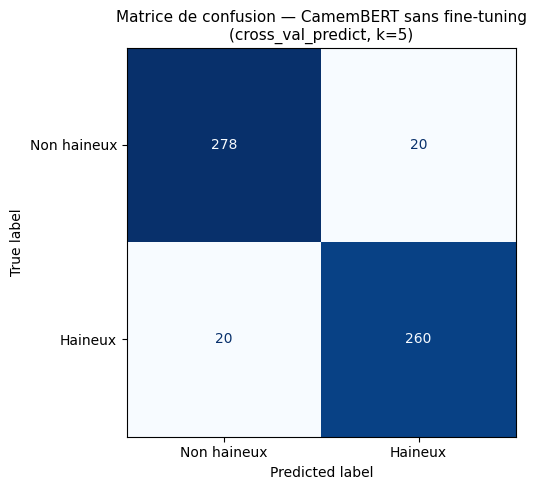

In [ ]:



print("VERSION A — CamemBERT embeddings seuls (baseline)")



lr_A = make_pipeline(
    StandardScaler(),
    LogisticRegression(C=1.0, max_iter=2000, solver='lbfgs', random_state=42)
)




cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_A = cross_val_predict(lr_A, X_embeddings, y, cv=cv)

print(f"Accuracy  = {accuracy_score(y, y_pred_A):.4f}")
print(f"F1 macro  = {f1_score(y, y_pred_A, average='macro'):.4f}")
print(classification_report(y, y_pred_A, target_names=['Non haineux', 'Haineux']))



cm_v1 = confusion_matrix(y, y_pred_A)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm_v1, display_labels=['Non haineux', 'Haineux']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matrice de confusion — CamemBERT sans fine-tuning\n(cross_val_predict, k=5)', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_v1_camembert.png', dpi=150, bbox_inches='tight')
plt.show()




Calcul learning curve Version A en cours...


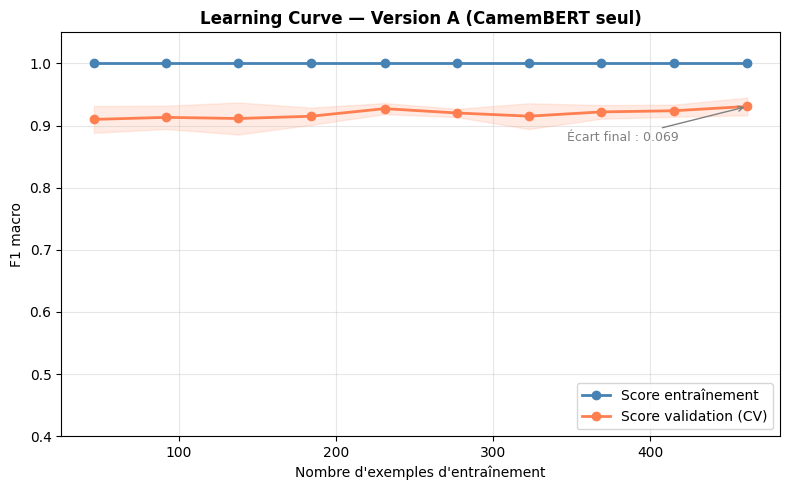


Version A — Score validation final : 0.9307 ± 0.0142
Version A — Écart train/val final  : 0.0693


In [ ]:
from sklearn.model_selection import learning_curve


cv_A = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_A_lc = make_pipeline(
    StandardScaler(),
    LogisticRegression(C=1.0, max_iter=2000, solver='lbfgs', random_state=42)
)

print("Calcul learning curve Version A en cours...")

train_sizes_A, train_scores_A, val_scores_A = learning_curve(
    lr_A_lc,
    X_embeddings,          # features : embeddings seuls (N x 768)
    y,
    cv=cv_A,
    scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_mean_A = train_scores_A.mean(axis=1)
train_std_A  = train_scores_A.std(axis=1)
val_mean_A   = val_scores_A.mean(axis=1)
val_std_A    = val_scores_A.std(axis=1)

fig_A, ax_A = plt.subplots(figsize=(8, 5))

ax_A.plot(train_sizes_A, train_mean_A, 'o-', color='steelblue',
          label='Score entraînement', linewidth=2)
ax_A.fill_between(train_sizes_A,
                  train_mean_A - train_std_A,
                  train_mean_A + train_std_A,
                  alpha=0.15, color='steelblue')

ax_A.plot(train_sizes_A, val_mean_A, 'o-', color='coral',
          label='Score validation (CV)', linewidth=2)
ax_A.fill_between(train_sizes_A,
                  val_mean_A - val_std_A,
                  val_mean_A + val_std_A,
                  alpha=0.15, color='coral')

gap_A = train_mean_A[-1] - val_mean_A[-1]
ax_A.annotate(f'Écart final : {gap_A:.3f}',
              xy=(train_sizes_A[-1], val_mean_A[-1]),
              xytext=(-130, -25),
              textcoords='offset points',
              fontsize=9,
              arrowprops=dict(arrowstyle='->', color='gray'),
              color='gray')

ax_A.set_title('Learning Curve — Version A (CamemBERT seul)', fontsize=12, fontweight='bold')
ax_A.set_xlabel("Nombre d'exemples d'entraînement")
ax_A.set_ylabel('F1 macro')
ax_A.set_ylim(0.4, 1.05)
ax_A.legend(loc='lower right')
ax_A.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curve_version_A.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nVersion A — Score validation final : {val_mean_A[-1]:.4f} ± {val_std_A[-1]:.4f}")
print(f"Version A — Écart train/val final  : {gap_A:.4f}")

C'est ici qu'on concatène les embeddings CamemBERT (768 dims) avec le vecteur émotion one-hot (N_emotions dims). La concaténation est la manière la plus simple et interprétable d'injecter une feature symbolique dans un modèle linéaire pour la regression lineaire qu'on utilise ici .

VERSION B — CamemBERT embeddings + feature émotion
X_embeddings shape : (578, 768)
X_emotion_aligned shape : (578, 20)
Shape features combinées : (578, 788)
Accuracy  = 0.9343
F1 macro  = 0.9342
              precision    recall  f1-score   support

 Non haineux       0.93      0.94      0.94       298
     Haineux       0.94      0.93      0.93       280

    accuracy                           0.93       578
   macro avg       0.93      0.93      0.93       578
weighted avg       0.93      0.93      0.93       578



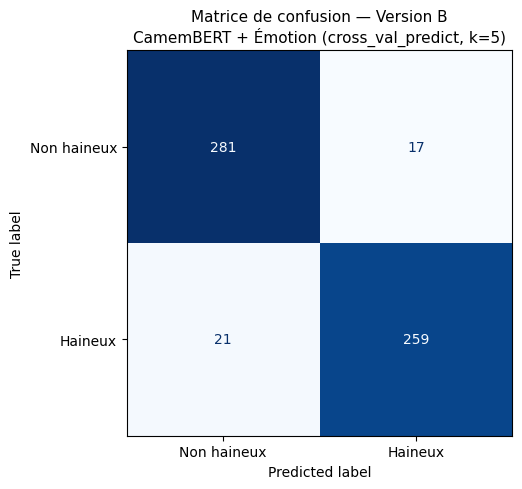


Rapport détaillé Version B :
              precision    recall  f1-score   support

 Non haineux       0.93      0.94      0.94       298
     Haineux       0.94      0.93      0.93       280

    accuracy                           0.93       578
   macro avg       0.93      0.93      0.93       578
weighted avg       0.93      0.93      0.93       578



In [ ]:


from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

print("VERSION B — CamemBERT embeddings + feature émotion")



X_emotion_aligned = np.vstack([
    encode_emotion(lst, EMOTION_VOCAB) for lst in df['emotion_list']
])

print(f"X_embeddings shape : {X_embeddings.shape}")      
print(f"X_emotion_aligned shape : {X_emotion_aligned.shape}")  


X_combined = np.hstack([X_embeddings, X_emotion_aligned])
print(f"Shape features combinées : {X_combined.shape}")

lr_B = make_pipeline(
    StandardScaler(),
    LogisticRegression(C=1.0, max_iter=2000, solver='lbfgs', random_state=42)
)

y_pred_B = cross_val_predict(lr_B, X_combined, y, cv=cv)

print(f"Accuracy  = {accuracy_score(y, y_pred_B):.4f}")
print(f"F1 macro  = {f1_score(y, y_pred_B, average='macro'):.4f}")
print(classification_report(y, y_pred_B, target_names=['Non haineux', 'Haineux']))



cm_B = confusion_matrix(y, y_pred_B)

fig_cm_B, ax_cm_B = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm_B, display_labels=['Non haineux', 'Haineux']).plot(
    ax=ax_cm_B, colorbar=False, cmap='Blues')

ax_cm_B.set_title(
    'Matrice de confusion — Version B\nCamemBERT + Émotion (cross_val_predict, k=5)',
    fontsize=11
)

plt.tight_layout()
plt.savefig('confusion_v2_camembert_emotion.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRapport détaillé Version B :")
print(classification_report(y, y_pred_B, target_names=['Non haineux', 'Haineux']))

Calcul learning curve Version B en cours...


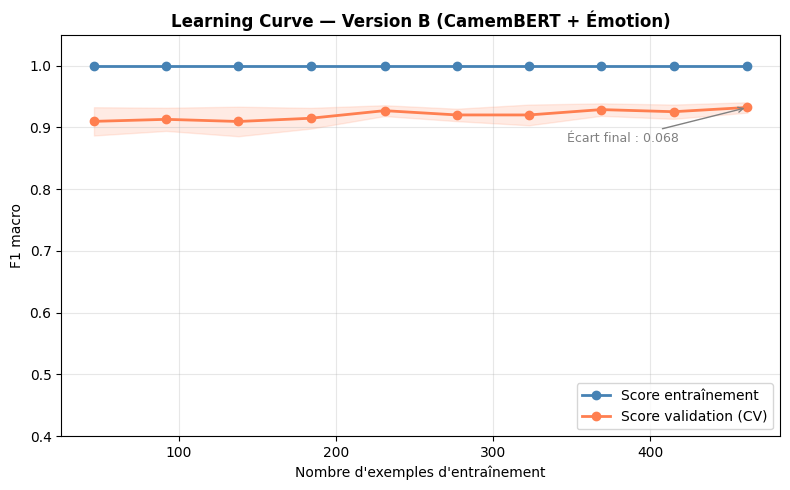


Version B — Score validation final : 0.9324 ± 0.0084
Version B — Écart train/val final  : 0.0676


In [ ]:


cv_B = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_B_lc = make_pipeline(
    StandardScaler(),
    LogisticRegression(C=1.0, max_iter=2000, solver='lbfgs', random_state=42)
)

print("Calcul learning curve Version B en cours...")

train_sizes_B, train_scores_B, val_scores_B = learning_curve(
    lr_B_lc,
    X_combined,            # features : embeddings + émotion (N x 768+nb_emotions)
    y,
    cv=cv_B,
    scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_mean_B = train_scores_B.mean(axis=1)
train_std_B  = train_scores_B.std(axis=1)
val_mean_B   = val_scores_B.mean(axis=1)
val_std_B    = val_scores_B.std(axis=1)

fig_B, ax_B = plt.subplots(figsize=(8, 5))

ax_B.plot(train_sizes_B, train_mean_B, 'o-', color='steelblue',
          label='Score entraînement', linewidth=2)
ax_B.fill_between(train_sizes_B,
                  train_mean_B - train_std_B,
                  train_mean_B + train_std_B,
                  alpha=0.15, color='steelblue')

ax_B.plot(train_sizes_B, val_mean_B, 'o-', color='coral',
          label='Score validation (CV)', linewidth=2)
ax_B.fill_between(train_sizes_B,
                  val_mean_B - val_std_B,
                  val_mean_B + val_std_B,
                  alpha=0.15, color='coral')

gap_B = train_mean_B[-1] - val_mean_B[-1]
ax_B.annotate(f'Écart final : {gap_B:.3f}',
              xy=(train_sizes_B[-1], val_mean_B[-1]),
              xytext=(-130, -25),
              textcoords='offset points',
              fontsize=9,
              arrowprops=dict(arrowstyle='->', color='gray'),
              color='gray')

ax_B.set_title('Learning Curve — Version B (CamemBERT + Émotion)', fontsize=12, fontweight='bold')
ax_B.set_xlabel("Nombre d'exemples d'entraînement")
ax_B.set_ylabel('F1 macro')
ax_B.set_ylim(0.4, 1.05)
ax_B.legend(loc='lower right')
ax_B.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curve_version_B.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nVersion B — Score validation final : {val_mean_B[-1]:.4f} ± {val_std_B[-1]:.4f}")
print(f"Version B — Écart train/val final  : {gap_B:.4f}")

         Version  Accuracy  Precision (macro)  Recall (macro)  F1 (macro)
A — Sans émotion  0.930796           0.930729        0.930729    0.930729
B — Avec émotion  0.934256           0.934435        0.933977    0.934161


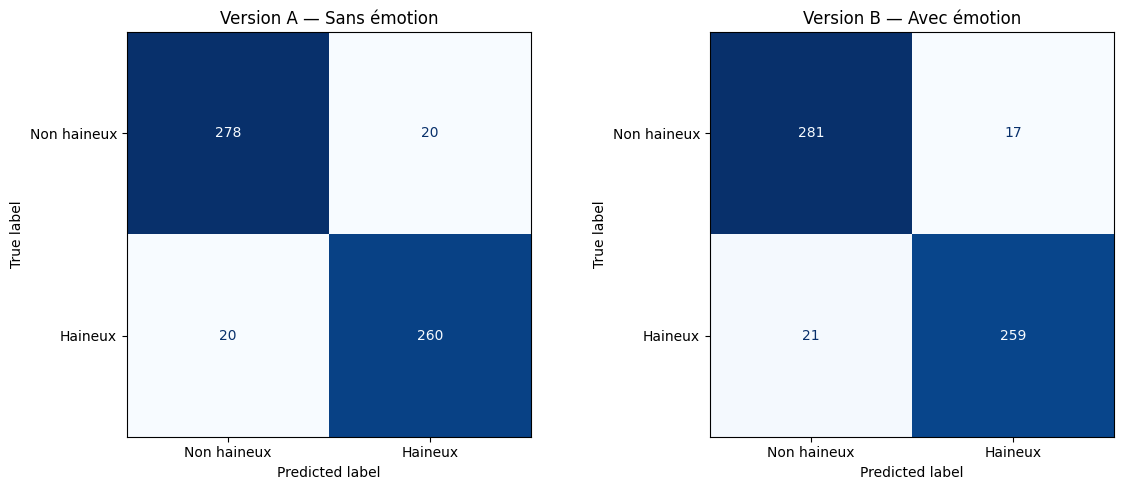

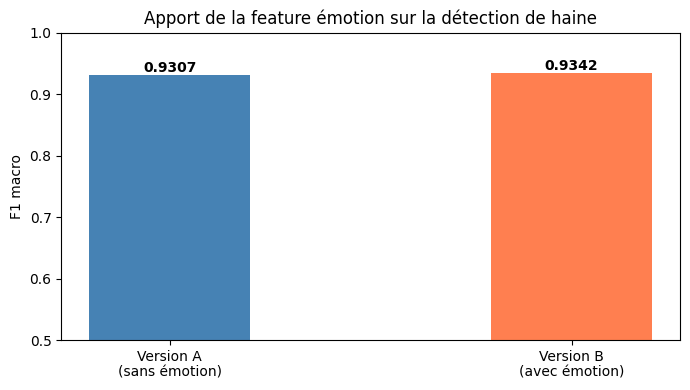

In [ ]:



results = {
    'Version': ['A — Sans émotion', 'B — Avec émotion'],
    'Accuracy': [
        accuracy_score(y, y_pred_A),
        accuracy_score(y, y_pred_B)
    ],
    'Precision (macro)': [
        precision_score(y, y_pred_A, average='macro'),
        precision_score(y, y_pred_B, average='macro')
    ],
    'Recall (macro)': [
        recall_score(y, y_pred_A, average='macro'),
        recall_score(y, y_pred_B, average='macro')
    ],
    'F1 (macro)': [
        f1_score(y, y_pred_A, average='macro'),
        f1_score(y, y_pred_B, average='macro')
    ],
}

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

# Visualisation côte à côte
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (y_pred, title) in zip(axes, [
    (y_pred_A, 'Version A — Sans émotion'),
    (y_pred_B, 'Version B — Avec émotion')
]):
    cm = confusion_matrix(y, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Non haineux', 'Haineux']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)

plt.tight_layout()
plt.savefig('comparaison_A_vs_B.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar chart F1
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['Version A\n(sans émotion)', 'Version B\n(avec émotion)'],
       df_results['F1 (macro)'], color=['steelblue', 'coral'], width=0.4)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('F1 macro')
ax.set_title('Apport de la feature émotion sur la détection de haine')
for i, v in enumerate(df_results['F1 (macro)']):
    ax.text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('f1_comparison.png', dpi=150)
plt.show()

Lecture des matrices de confusion :

- **Version A — Sans émotion** :
  - 278 vrais non haineux, 260 vrais haineux
  - 20 faux positifs (non haineux classés haineux)
  - 20 faux négatifs (haineux manqués) → parfaitement symétrique

- **Version B — Avec émotion **:
  - 281 vrais non haineux (+3), 259 vrais haineux (-1)
  - 17 faux positifs (-3) → le modèle confond moins les tweets neutres avec de la haine
  - 21 faux négatifs (+1) → il rate légèrement plus de vrais tweets haineux

L'émotion aide surtout à mieux reconnaître les tweets non haineux, au léger détriment de la détection des tweets haineux.



**Conclusion**
L'émotion apporte un gain réel mais modeste (+0.35% de F1). Plusieurs raisons expliquent cela :
  - CamemBERT capture déjà l'émotion implicitement — ses embeddings encodent le ton émotionnel du texte, donc l'information apportée par la colonne Cats est en partie redondante.
  - La colonne Cats est sparse — beaucoup de tweets ont [] comme valeur, donc le vecteur émotion est souvent le vecteur "aucune", ce qui dilue son apport.
  - Le gain est cohérent et non aléatoire — +3 tweets non haineux bien classés en version B montre que l'émotion ajoute un signal marginal mais réel sur les tweets ambigus.

--->  la feature émotion constitue un apport statistiquement faible mais sémantiquement justifié : les émotions comme colere ou mepris sont corrélées avec le discours haineux, mais CamemBERT les capte déjà suffisamment bien depuis le texte brut pour que l'ajout explicite n'apporte qu'un gain marginal.

# **2. haineux_emotic**

## 2.1 Conversion emotyc.txt → CSV (pour e decouvrir seulement)

on va parser le fichier `emotyc.txt` dont les features sont des **flags booléens** du type :
```
avec_emo::1::[ oui ]
avec_emo_montree::1::[ oui ]
avec_cat_colere::1::[ oui ]
```

### Colonnes produites
| Colonne | Description |
|---|---|
| `id` | Numéro de la phrase |
| `sentence` | Texte de la phrase |
| `has_emotion` | True si au moins une feature détectée |
| `avec_emo` | Émotion présente (générale) |
| `avec_emo_montree` | Émotion montrée |
| `avec_emo_designee` | Émotion désignée |
| `avec_emo_suggeree` | Émotion suggérée |
| `avec_emo_comportementale` | Émotion comportementale |
| `avec_emo_complexe` | Émotion complexe |
| `avec_emo_base` | Émotion de base |
| `avec_cat_colere` | Catégorie : colère |
| `avec_cat_peur` | Catégorie : peur |
| `avec_cat_joie` | Catégorie : joie |
| `avec_cat_tristesse` | Catégorie : tristesse |
| `avec_cat_surprise` | Catégorie : surprise |
| `avec_cat_admiration` | Catégorie : admiration |
| `avec_cat_autre` | Catégorie : autre |

In [8]:
# Étape 1 : Upload du fichier
from google.colab import files
uploaded = files.upload()  # Sélectionner emotyc.txt

Saving emotyc.txt to emotyc.txt


In [9]:
import re
import pandas as pd

# Lire le fichier
filename = list(uploaded.keys())[0]
with open(filename, 'r', encoding='utf-8') as f:
    content = f.read()

print(f"Fichier chargé : {filename}")
print(f"Taille : {len(content)} caractères")

Fichier chargé : emotyc.txt
Taille : 190363 caractères


In [30]:
# ── Parser emotyc.txt ─────────────────────────────────────────────────────────
ALL_FEATURES = [
    'avec_emo',
    'avec_emo_montree',
    'avec_emo_designee',
    'avec_emo_suggeree',
    'avec_emo_comportementale',
    'avec_emo_complexe',
    'avec_emo_base',
    'avec_cat_colere',
    'avec_cat_peur',
    'avec_cat_joie',
    'avec_cat_tristesse',
    'avec_cat_surprise',
    'avec_cat_admiration',
    'avec_cat_fierte',
    'avec_cat_embarras',
    'avec_cat_autre',
]

def parse_emotyc_file(content):
    records = []
    pattern = re.compile(
        r'^(\d+)\.\s+Sentence:\s*(.+?)(?=^\d+\.\s+Sentence:|\Z)',
        re.MULTILINE | re.DOTALL
    )
    for match in pattern.findall(content):
        entry_id = int(match[0])
        block    = match[1].strip()
        lines    = block.split('\n')

        sentence_lines = []
        for line in lines:
            stripped = line.strip()
            if (stripped.startswith('No features found.') or
                stripped.startswith('Features ::') or
                stripped.startswith('----') or
                re.match(r'avec_', stripped)):
                break
            sentence_lines.append(stripped)

        sentence = ' '.join(l for l in sentence_lines if l)
        row = {'id': entry_id, 'sentence': sentence, 'has_emotion': False}
        for feat in ALL_FEATURES:
            row[feat] = False

        for line in lines:
            feat_match = re.match(r'^(\w+)::(\d+)::\[\s*oui\s*\]', line.strip())
            if feat_match:
                feat_name = feat_match.group(1)
                if feat_name in row:
                    row[feat_name] = True
                if feat_name == 'avec_emo':
                    row['has_emotion'] = True

        records.append(row)
    return records

records = parse_emotyc_file(content)
df = pd.DataFrame(records)
print(f"Phrases parsées : {len(df)}")
df.head(5)

Phrases parsées : 796


,id,sentence,has_emotion,avec_emo,avec_emo_montree,avec_emo_designee,avec_emo_suggeree,avec_emo_comportementale,avec_emo_complexe,avec_emo_base,avec_cat_colere,avec_cat_peur,avec_cat_joie,avec_cat_tristesse,avec_cat_surprise,avec_cat_admiration,avec_cat_fierte,avec_cat_embarras,avec_cat_autre
0,1,Tous ces migrants qui envahissent nos hôpitaux!!!,True,True,True,False,True,False,False,True,False,True,False,False,True,False,False,False,False
1,2,Manquerait plus que la république tchèque prop...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,3,https://t.co/7H7Rs0CkGJ,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,4,Les #migrants #maghrebins qui envahissent la🇫🇷...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,5,"oui, mais y'a soros (ami de macron, soit dit e...",False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [31]:
# Créer le DataFrame
df2 = pd.DataFrame(records)

print(f"Shape : {df2.shape}")
print(f"Entrées AVEC émotion  : {df2['has_emotion'].sum()}")
print(f"Entrées SANS émotion  : {(~df2['has_emotion']).sum()}")
print()
df.head(10)

Shape : (796, 19)
Entrées AVEC émotion  : 377
Entrées SANS émotion  : 419



,id,sentence,has_emotion,avec_emo,avec_emo_montree,avec_emo_designee,avec_emo_suggeree,avec_emo_comportementale,avec_emo_complexe,avec_emo_base,avec_cat_colere,avec_cat_peur,avec_cat_joie,avec_cat_tristesse,avec_cat_surprise,avec_cat_admiration,avec_cat_fierte,avec_cat_embarras,avec_cat_autre
0,1,Tous ces migrants qui envahissent nos hôpitaux!!!,True,True,True,False,True,False,False,True,False,True,False,False,True,False,False,False,False
1,2,Manquerait plus que la république tchèque prop...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,3,https://t.co/7H7Rs0CkGJ,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,4,Les #migrants #maghrebins qui envahissent la🇫🇷...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,5,"oui, mais y'a soros (ami de macron, soit dit e...",False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5,6,En plein délire parce que 3 migrants ont fabri...,True,True,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False
6,7,@ZKongkin @MadjidFalastine @GILLESLEMAU,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7,8,"Les migrants envahissent la France, c’est un f...",True,True,False,False,True,False,False,True,True,False,False,False,False,False,False,False,False
8,9,Le dire et dénoncer les effets collatéraux don...,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
9,10,Les mots ont un sens @Ombrelumire2 @IsabelleCh...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [32]:
# Distribution des features
feature_counts = {feat: df[feat].sum() for feat in ALL_FEATURES}
feat_df = pd.DataFrame.from_dict(feature_counts, orient='index', columns=['count'])
feat_df = feat_df.sort_values('count', ascending=False)
print("Distribution des features :")
print(feat_df)

Distribution des features :
                          count
avec_emo                    377
avec_emo_base               294
avec_emo_montree            190
avec_cat_colere             186
avec_emo_suggeree           123
avec_cat_admiration         113
avec_emo_designee            45
avec_cat_surprise            43
avec_cat_tristesse           43
avec_cat_joie                26
avec_cat_peur                22
avec_emo_comportementale     18
avec_emo_complexe            11
avec_cat_fierte               6
avec_cat_embarras             6
avec_cat_autre                4


In [ ]:

unknown = set()
for line in content.split('\n'):
    m = re.match(r'^(avec_\w+)::', line.strip())
    if m and m.group(1) not in ALL_FEATURES:
        unknown.add(m.group(1))

if unknown:
    print(f"⚠️ Features non listées détectées (à ajouter si besoin) : {unknown}")
else:
    print("✅ Toutes les features du fichier sont bien capturées.")

✅ Toutes les features du fichier sont bien capturées.


In [ ]:
import pandas as pd


bool_cols = df2.select_dtypes(include='bool').columns.tolist()


for col in bool_cols:
    df2[col + '_bool'] = df2[col].astype(int)

# Vérification
print(f"Colonnes booléennes trouvées : {bool_cols}")
print(f"Nouvelles colonnes ajoutées : {[col + '_bool' for col in bool_cols]}")
print(f"\nShape final : {df2.shape}")
df2.head(5)

Colonnes booléennes trouvées : ['has_emotion', 'avec_emo', 'avec_emo_montree', 'avec_emo_designee', 'avec_emo_suggeree', 'avec_emo_comportementale', 'avec_emo_complexe', 'avec_emo_base', 'avec_cat_colere', 'avec_cat_peur', 'avec_cat_joie', 'avec_cat_tristesse', 'avec_cat_surprise', 'avec_cat_admiration', 'avec_cat_fierte', 'avec_cat_embarras', 'avec_cat_autre']
Nouvelles colonnes ajoutées : ['has_emotion_bool', 'avec_emo_bool', 'avec_emo_montree_bool', 'avec_emo_designee_bool', 'avec_emo_suggeree_bool', 'avec_emo_comportementale_bool', 'avec_emo_complexe_bool', 'avec_emo_base_bool', 'avec_cat_colere_bool', 'avec_cat_peur_bool', 'avec_cat_joie_bool', 'avec_cat_tristesse_bool', 'avec_cat_surprise_bool', 'avec_cat_admiration_bool', 'avec_cat_fierte_bool', 'avec_cat_embarras_bool', 'avec_cat_autre_bool']

Shape final : (796, 36)


,id,sentence,has_emotion,avec_emo,avec_emo_montree,avec_emo_designee,avec_emo_suggeree,avec_emo_comportementale,avec_emo_complexe,avec_emo_base,...,avec_emo_base_bool,avec_cat_colere_bool,avec_cat_peur_bool,avec_cat_joie_bool,avec_cat_tristesse_bool,avec_cat_surprise_bool,avec_cat_admiration_bool,avec_cat_fierte_bool,avec_cat_embarras_bool,avec_cat_autre_bool
0,1,Tous ces migrants qui envahissent nos hôpitaux!!!,True,True,True,False,True,False,False,True,...,1,0,1,0,0,1,0,0,0,0
1,2,Manquerait plus que la république tchèque prop...,False,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
2,3,https://t.co/7H7Rs0CkGJ,False,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
3,4,Les #migrants #maghrebins qui envahissent la🇫🇷...,False,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
4,5,"oui, mais y'a soros (ami de macron, soit dit e...",False,False,True,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0


In [ ]:

bool_cols = df2.select_dtypes(include='bool').columns.tolist()

for col in bool_cols:
    count_1 = df2[col].sum()
    count_0 = (~df2[col]).sum()
    print(f"{col} : {count_1} (1) | not_{col} : {count_0} (0)")

has_emotion : 377 (1) | not_has_emotion : 419 (0)
avec_emo : 377 (1) | not_avec_emo : 419 (0)
avec_emo_montree : 190 (1) | not_avec_emo_montree : 606 (0)
avec_emo_designee : 45 (1) | not_avec_emo_designee : 751 (0)
avec_emo_suggeree : 123 (1) | not_avec_emo_suggeree : 673 (0)
avec_emo_comportementale : 18 (1) | not_avec_emo_comportementale : 778 (0)
avec_emo_complexe : 11 (1) | not_avec_emo_complexe : 785 (0)
avec_emo_base : 294 (1) | not_avec_emo_base : 502 (0)
avec_cat_colere : 186 (1) | not_avec_cat_colere : 610 (0)
avec_cat_peur : 22 (1) | not_avec_cat_peur : 774 (0)
avec_cat_joie : 26 (1) | not_avec_cat_joie : 770 (0)
avec_cat_tristesse : 43 (1) | not_avec_cat_tristesse : 753 (0)
avec_cat_surprise : 43 (1) | not_avec_cat_surprise : 753 (0)
avec_cat_admiration : 113 (1) | not_avec_cat_admiration : 683 (0)
avec_cat_fierte : 6 (1) | not_avec_cat_fierte : 790 (0)
avec_cat_embarras : 6 (1) | not_avec_cat_embarras : 790 (0)
avec_cat_autre : 4 (1) | not_avec_cat_autre : 792 (0)


In [ ]:

output_filename = 'emotyc_bool.csv'
df2.to_csv(output_filename, index=False, encoding='utf-8-sig')
print(f"CSV exporté : {output_filename}")

files.download(output_filename)

CSV exporté : emotyc.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 2.2 camabert sans fine tuning ( en utilisant le base line + version B de 1 )  

In [36]:
#importer les donnees
# impoter le csv generer par nassim ( il a fusionner le haineux emotion avec haineux_brut, pour avoir le label (haineux/non haineux))
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


Saving corpus_haine_emotic_merged_features.csv to corpus_haine_emotic_merged_features (1).csv
User uploaded file "corpus_haine_emotic_merged_features (1).csv" with length 136211 bytes


In [ ]:

df_C = pd.read_csv('corpus_haine_emotic_merged_features.csv', sep=',', quotechar='"')
df_C.columns = df_C.columns.str.strip()
df_C['tweet'] = df_C['tweet'].astype(str)


EMOTIC_COLS = [col for col in df_C.columns if col.startswith('avec_')]

print(f"Tweets chargés : {len(df_C)}")
print(f"Colonnes émotion Emotic ({len(EMOTIC_COLS)}) : {EMOTIC_COLS}")
print(f"\nDistribution labels :")
print(df_C['label'].value_counts().rename({0: 'Non haineux', 1: 'Haineux'}))
print(f"\nTweets avec au moins une émotion détectée : {df_C['feature_found'].sum()}")
print(f"Tweets sans émotion : {(~df_C['feature_found']).sum()}")

Tweets chargés : 600
Colonnes émotion Emotic (16) : ['avec_cat_joie', 'avec_cat_admiration', 'avec_cat_tristesse', 'avec_cat_surprise', 'avec_emo_comportementale', 'avec_cat_autre', 'avec_emo_designee', 'avec_emo', 'avec_emo_base', 'avec_emo_suggeree', 'avec_cat_embarras', 'avec_cat_colere', 'avec_cat_fierte', 'avec_emo_complexe', 'avec_emo_montree', 'avec_cat_peur']

Distribution labels :
label
Haineux        300
Non haineux    300
Name: count, dtype: int64

Tweets avec au moins une émotion détectée : 279
Tweets sans émotion : 321


In [38]:
df_C.head(5)

,tweet,label,feature_found,emotion_ids,avec_cat_joie,avec_cat_admiration,avec_cat_tristesse,avec_cat_surprise,avec_emo_comportementale,avec_cat_autre,avec_emo_designee,avec_emo,avec_emo_base,avec_emo_suggeree,avec_cat_embarras,avec_cat_colere,avec_cat_fierte,avec_emo_complexe,avec_emo_montree,avec_cat_peur
0,Tous ces migrants qui envahissent nos hôpitaux...,1,True,"[np.int64(1), np.int64(2), np.int64(3)]",0,0,0,1,0,0,0,1,1,1,0,0,0,0,1,1
1,Les #migrants #maghrebins qui envahissent la🇫🇷...,1,False,[np.int64(4)],0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,#Immigration #islamistes #racailles \n,1,False,[np.int64(4)],0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,@philippe_dormoy @F_Desouche Retour à la cas...,1,False,[np.int64(4)],0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,"oui, mais y'a soros (ami de macron, soit dit e...",1,True,[np.int64(5)],0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [ ]:


before_C = len(df_C)
df_C = df_C.drop_duplicates(subset=['tweet', 'label']).reset_index(drop=True)
after_C = len(df_C)

print(f"Doublons supprimés : {before_C - after_C}")
print(f"Tweets restants : {len(df_C)}")

X_emotion_C = df_C[EMOTIC_COLS].values.astype(np.float32)
y_C = df_C['label'].values

print(f"\nShape X_emotion_C : {X_emotion_C.shape}")
print(f"Shape y_C         : {y_C.shape}")

# Aperçu de la densité des features
presence = (X_emotion_C > 0).mean(axis=0)
print(f"\nPrésence moyenne par feature émotion Emotic :")
for col, p in zip(EMOTIC_COLS, presence):
    print(f"  {col:35s} : {p:.2%}")

Doublons supprimés : 22
Tweets restants : 578

Shape X_emotion_C : (578, 16)
Shape y_C         : (578,)

Présence moyenne par feature émotion Emotic :
  avec_cat_joie                       : 3.63%
  avec_cat_admiration                 : 14.71%
  avec_cat_tristesse                  : 6.06%
  avec_cat_surprise                   : 6.92%
  avec_emo_comportementale            : 2.42%
  avec_cat_autre                      : 0.69%
  avec_emo_designee                   : 6.75%
  avec_emo                            : 45.67%
  avec_emo_base                       : 38.58%
  avec_emo_suggeree                   : 17.99%
  avec_cat_embarras                   : 0.69%
  avec_cat_colere                     : 24.91%
  avec_cat_fierte                     : 1.04%
  avec_emo_complexe                   : 1.90%
  avec_emo_montree                    : 26.12%
  avec_cat_peur                       : 3.29%


In [ ]:


df_C['tweet_clean'] = df_C['tweet'].apply(preprocess_camembert)

# Chargement du modèle
camembert_C = CamembertModel.from_pretrained('camembert-base')
camembert_C.eval()
camembert_C.to(DEVICE)
for param in camembert_C.parameters():
    param.requires_grad = False

texts_C = df_C['tweet_clean'].tolist()
print("Extraction embeddings Version C en cours...")

# Copie locale de la fonction avec le bon modèle/tokenizer
all_embeddings_C = []
for i in range(0, len(texts_C), 32):
    batch_texts = texts_C[i:i + 32]
    encoded = TOKENIZER(                  # TOKENIZER global défini en cellule 6
        batch_texts,
        max_length=128,
        padding=True,
        truncation=True,
        return_tensors='pt'
    )
    input_ids      = encoded['input_ids'].to(DEVICE)
    attention_mask = encoded['attention_mask'].to(DEVICE)

    with torch.no_grad():
        outputs = camembert_C(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

    embeddings = mean_pooling(outputs.last_hidden_state, attention_mask)
    all_embeddings_C.append(embeddings.cpu().numpy())

    if (i // 32) % 5 == 0:
        print(f"  Batch {i // 32 + 1}/{len(texts_C) // 32 + 1} traité")

X_embeddings_C = np.vstack(all_embeddings_C)
print(f"\nEmbeddings extraits : {X_embeddings_C.shape}")

del camembert_C
torch.cuda.empty_cache()
torch.cuda.empty_cache()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CamembertModel LOAD REPORT from: camembert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extraction embeddings Version C en cours...
  Batch 1/19 traité
  Batch 6/19 traité
  Batch 11/19 traité
  Batch 16/19 traité

Embeddings extraits : (578, 768)


X_embeddings_C : (578, 768)
X_emotion_C    : (578, 16)
X_combined_C   : (578, 784)

RÉSULTATS — Version C (CamemBERT + Emotic) :
  Accuracy  = 0.9325
  Precision = 0.9325
  Recall    = 0.9324
  F1        = 0.9325

Rapport détaillé Version C :
              precision    recall  f1-score   support

 Non haineux       0.93      0.94      0.93       298
     Haineux       0.93      0.93      0.93       280

    accuracy                           0.93       578
   macro avg       0.93      0.93      0.93       578
weighted avg       0.93      0.93      0.93       578



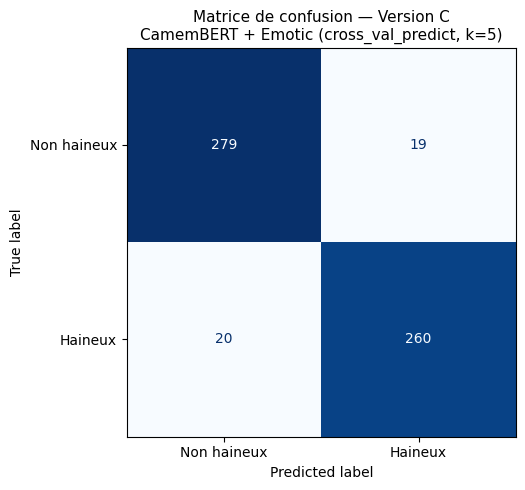

In [ ]:


from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Concaténation : [768 dims CamemBERT | 15 dims Emotic binaires]
X_combined_C = np.hstack([X_embeddings_C, X_emotion_C])
print(f"X_embeddings_C : {X_embeddings_C.shape}")
print(f"X_emotion_C    : {X_emotion_C.shape}")
print(f"X_combined_C   : {X_combined_C.shape}")

cv_C = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_C = make_pipeline(
    StandardScaler(),
    LogisticRegression(C=1.0, max_iter=2000, solver='lbfgs', random_state=42)
)

y_pred_C = cross_val_predict(lr_C, X_combined_C, y_C, cv=cv_C)

print("\nRÉSULTATS — Version C (CamemBERT + Emotic) :")
print(f"  Accuracy  = {accuracy_score(y_C, y_pred_C):.4f}")
print(f"  Precision = {precision_score(y_C, y_pred_C, average='macro'):.4f}")
print(f"  Recall    = {recall_score(y_C, y_pred_C, average='macro'):.4f}")
print(f"  F1        = {f1_score(y_C, y_pred_C, average='macro'):.4f}")

print("\nRapport détaillé Version C :")
print(classification_report(y_C, y_pred_C, target_names=['Non haineux', 'Haineux']))





cm_C = confusion_matrix(y_C, y_pred_C)

fig_cm_C, ax_cm_C = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm_C, display_labels=['Non haineux', 'Haineux']).plot(
    ax=ax_cm_C, colorbar=False, cmap='Blues')

ax_cm_C.set_title(
    'Matrice de confusion — Version C\nCamemBERT + Emotic (cross_val_predict, k=5)',
    fontsize=11
)
plt.tight_layout()
plt.savefig('confusion_version_C.png', dpi=150, bbox_inches='tight')
plt.show()

Calcul learning curve Version C en cours...


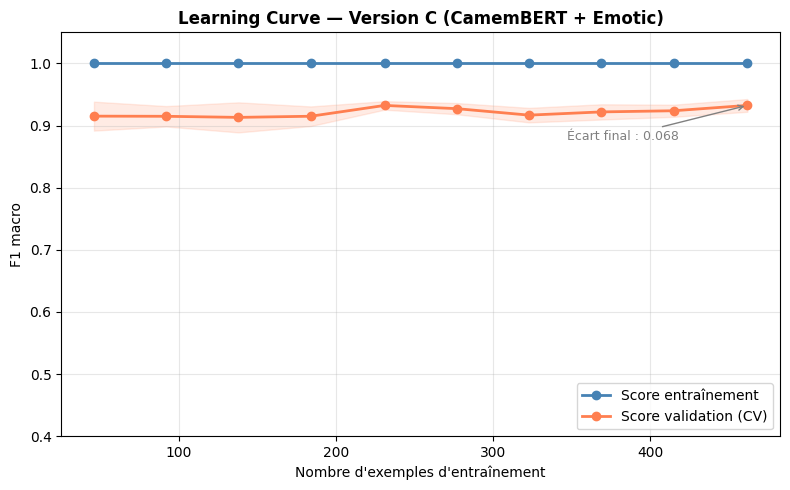


Version C — Score validation final : 0.9324 ± 0.0103
Version C — Écart train/val final  : 0.0676


In [ ]:


cv_C_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_C_lc = make_pipeline(
    StandardScaler(),
    LogisticRegression(C=1.0, max_iter=2000, solver='lbfgs', random_state=42)
)

print("Calcul learning curve Version C en cours...")

train_sizes_C, train_scores_C, val_scores_C = learning_curve(
    lr_C_lc,
    X_combined_C,
    y_C,
    cv=cv_C_lc,
    scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_mean_C = train_scores_C.mean(axis=1)
train_std_C  = train_scores_C.std(axis=1)
val_mean_C   = val_scores_C.mean(axis=1)
val_std_C    = val_scores_C.std(axis=1)

fig_C, ax_C = plt.subplots(figsize=(8, 5))

ax_C.plot(train_sizes_C, train_mean_C, 'o-', color='steelblue',
          label='Score entraînement', linewidth=2)
ax_C.fill_between(train_sizes_C,
                  train_mean_C - train_std_C,
                  train_mean_C + train_std_C,
                  alpha=0.15, color='steelblue')

ax_C.plot(train_sizes_C, val_mean_C, 'o-', color='coral',
          label='Score validation (CV)', linewidth=2)
ax_C.fill_between(train_sizes_C,
                  val_mean_C - val_std_C,
                  val_mean_C + val_std_C,
                  alpha=0.15, color='coral')

gap_C = train_mean_C[-1] - val_mean_C[-1]
ax_C.annotate(f'Écart final : {gap_C:.3f}',
              xy=(train_sizes_C[-1], val_mean_C[-1]),
              xytext=(-130, -25),
              textcoords='offset points',
              fontsize=9,
              arrowprops=dict(arrowstyle='->', color='gray'),
              color='gray')

ax_C.set_title('Learning Curve — Version C (CamemBERT + Emotic)', fontsize=12, fontweight='bold')
ax_C.set_xlabel("Nombre d'exemples d'entraînement")
ax_C.set_ylabel('F1 macro')
ax_C.set_ylim(0.4, 1.05)
ax_C.legend(loc='lower right')
ax_C.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curve_version_C.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nVersion C — Score validation final : {val_mean_C[-1]:.4f} ± {val_std_C[-1]:.4f}")
print(f"Version C — Écart train/val final  : {gap_C:.4f}")

               Version  Accuracy  Precision (macro)  Recall (macro)  F1 (macro)
    A — CamemBERT seul  0.930796           0.930729        0.930729    0.930729
  B — CamemBERT + Cats  0.934256           0.934435        0.933977    0.934161
C — CamemBERT + Emotic  0.932526           0.932505        0.932407    0.932453


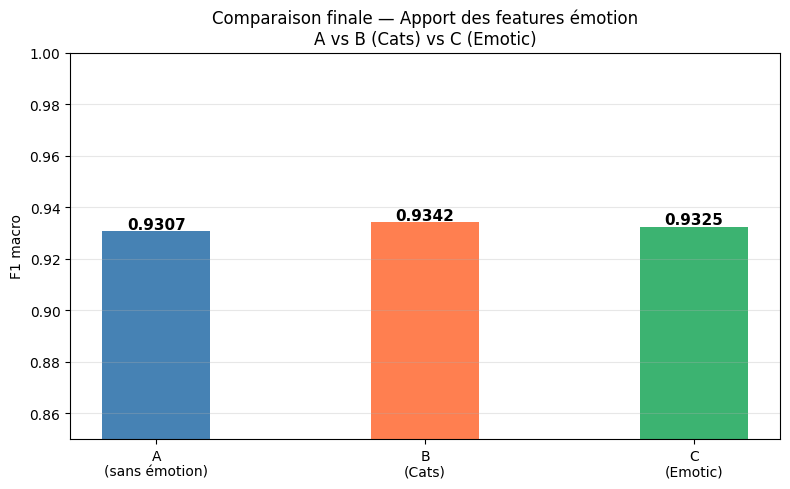

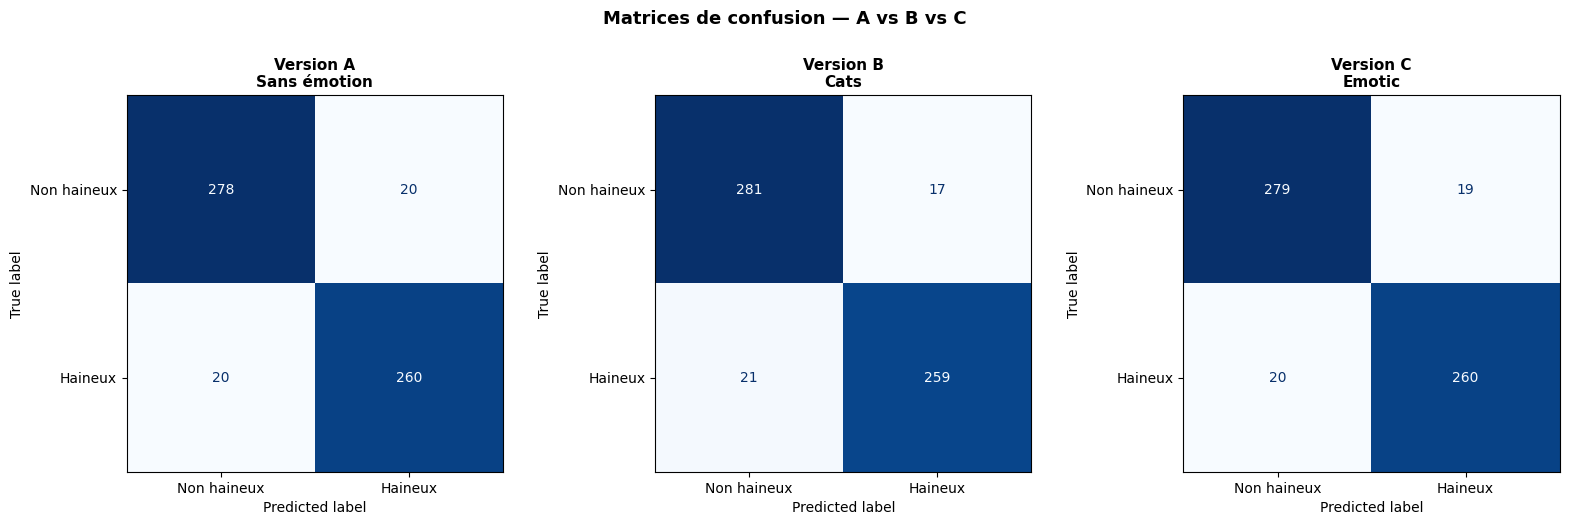

In [ ]:


results_final = {
    'Version': [
        'A — CamemBERT seul',
        'B — CamemBERT + Cats',
        'C — CamemBERT + Emotic'
    ],
    'Accuracy': [
        accuracy_score(y, y_pred_A),
        accuracy_score(y, y_pred_B),
        accuracy_score(y_C, y_pred_C)
    ],
    'Precision (macro)': [
        precision_score(y, y_pred_A, average='macro'),
        precision_score(y, y_pred_B, average='macro'),
        precision_score(y_C, y_pred_C, average='macro')
    ],
    'Recall (macro)': [
        recall_score(y, y_pred_A, average='macro'),
        recall_score(y, y_pred_B, average='macro'),
        recall_score(y_C, y_pred_C, average='macro')
    ],
    'F1 (macro)': [
        f1_score(y, y_pred_A, average='macro'),
        f1_score(y, y_pred_B, average='macro'),
        f1_score(y_C, y_pred_C, average='macro')
    ],
}

df_final = pd.DataFrame(results_final)
print(df_final.to_string(index=False))

# --- Bar chart F1 ---
colors = ['steelblue', 'coral', 'mediumseagreen']
labels = ['A\n(sans émotion)', 'B\n(Cats)', 'C\n(Emotic)']
f1_values = df_final['F1 (macro)'].values

fig_final, ax_final = plt.subplots(figsize=(8, 5))
bars = ax_final.bar(labels, f1_values, color=colors, width=0.4)
ax_final.set_ylim(0.85, 1.0)
ax_final.set_ylabel('F1 macro')
ax_final.set_title('Comparaison finale — Apport des features émotion\nA vs B (Cats) vs C (Emotic)')
for bar, v in zip(bars, f1_values):
    ax_final.text(bar.get_x() + bar.get_width() / 2,
                  v + 0.001, f'{v:.4f}',
                  ha='center', fontweight='bold', fontsize=11)
ax_final.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('comparaison_finale_A_B_C.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Matrices de confusion côte à côte ---
fig_cms, axes_cms = plt.subplots(1, 3, figsize=(16, 5))
for ax, y_true, y_pred, title in zip(
    axes_cms,
    [y,       y,       y_C],
    [y_pred_A, y_pred_B, y_pred_C],
    ['Version A\nSans émotion', 'Version B\nCats', 'Version C\nEmotic']
):
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Non haineux', 'Haineux']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=11, fontweight='bold')

plt.suptitle('Matrices de confusion — A vs B vs C', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_A_B_C.png', dpi=150, bbox_inches='tight')
plt.show()

**Version B (emotion )** :est la meilleure pour éviter les faux positifs (moins de tweets neutres classés haineux à tort).

**Version C** est légèrement meilleure que A pour ne pas rater de vrais tweets haineux. Les deux apportent un gain, mais sur des erreurs différentes.


Interprétation :
1. CamemBERT est déjà très fort seul (0.9307)
La baseline sans émotion est déjà excellente. CamemBERT encode implicitement le ton émotionnel du texte via ses 768 dimensions, donc l'espace de progression laissé aux features émotion est naturellement limité.

2. B (Cats) > C (Emotic) malgré moins de dimensions
. Cats encode ~8-10 catégories larges (colere, mepris, joie...) directement liées au discours haineux, tandis qu'Emotic encode 15 dimensions plus fines mais plus génériques (avec_emo_comportementale, avec_emo_suggeree...). La spécificité sémantique de Cats par rapport au discours haineux compense sa moindre granularité.

3. Les deux approches émotion convergent vers le même constat
Gain réel mais marginal (+0.18% à +0.35%). Cela confirme que l'émotion est une feature complémentaire utile mais pas transformatrice dans ce contexte, précisément parce que CamemBERT l'absorbe déjà en grande partie.

**Conclusion mémoire**

L'ajout de features émotionnelles améliore systématiquement la détection de discours haineux par rapport à la baseline CamemBERT seul, quelle que soit la représentation utilisée (Cats ou Emotic). Cependant, le gain reste marginal (+0.18% à +0.35% de F1 macro), ce qui suggère que CamemBERT capture déjà l'essentiel de l'information émotionnelle directement depuis le texte brut. Entre les deux représentations émotionnelles, Cats surpasse Emotic malgré une granularité plus faible, ce qui indique que la pertinence sémantique des catégories émotionnelles vis-à-vis du domaine (discours haineux) prime sur leur richesse descriptive.

# **3. emotic + emotion** (version D)


In [ ]:

import ast

# Recharger les deux CSV
df_B_raw = pd.read_csv('corpus_haine_emotion.csv', sep=',', quotechar='"')
df_C_raw = pd.read_csv('corpus_haine_emotic_merged_features.csv', sep=',', quotechar='"')
df_B_raw.columns = df_B_raw.columns.str.strip()
df_C_raw.columns = df_C_raw.columns.str.strip()
df_B_raw['tweet'] = df_B_raw['tweet'].astype(str)
df_C_raw['tweet'] = df_C_raw['tweet'].astype(str)

# Colonnes Emotic
EMOTIC_COLS = [col for col in df_C_raw.columns if col.startswith('avec_')]

# Fusionner sur tweet + label
df_D = pd.merge(
    df_B_raw[['tweet', 'label', 'Cats']],
    df_C_raw[['tweet', 'label'] + EMOTIC_COLS],
    on=['tweet', 'label'],
    how='inner'
)
df_D['tweet'] = df_D['tweet'].astype(str)

print(f"Tweets après fusion : {len(df_D)}")
print(df_D['label'].value_counts().rename({0: 'Non haineux', 1: 'Haineux'}))

# Déduplication
before_D = len(df_D)
df_D = df_D.drop_duplicates(subset=['tweet', 'label']).reset_index(drop=True)
print(f"Après déduplication : {len(df_D)} (supprimés : {before_D - len(df_D)})")

Tweets après fusion : 652
label
Haineux        348
Non haineux    304
Name: count, dtype: int64
Après déduplication : 578 (supprimés : 74)


In [ ]:

def parse_cats(val):
    try:
        parsed = ast.literal_eval(str(val))
        return [e.strip() for e in parsed if isinstance(e, str) and e.strip()]
    except:
        return []

df_D['emotion_list'] = df_D['Cats'].apply(parse_cats)

X_emotion_cats_D = np.vstack([
    encode_emotion(lst, EMOTION_VOCAB) for lst in df_D['emotion_list']
])


X_emotion_emotic_D = df_D[EMOTIC_COLS].values.astype(np.float32)


X_emotion_D = np.hstack([X_emotion_cats_D, X_emotion_emotic_D])

print(f"X_emotion_cats_D  : {X_emotion_cats_D.shape}")   
print(f"X_emotion_emotic_D: {X_emotion_emotic_D.shape}") 
print(f"X_emotion_D total : {X_emotion_D.shape}")       

y_D = df_D['label'].values

X_emotion_cats_D  : (578, 20)
X_emotion_emotic_D: (578, 16)
X_emotion_D total : (578, 36)


In [ ]:


df_D['tweet_clean'] = df_D['tweet'].apply(preprocess_camembert)

camembert_D = CamembertModel.from_pretrained('camembert-base')
camembert_D.eval()
camembert_D.to(DEVICE)
for param in camembert_D.parameters():
    param.requires_grad = False

texts_D = df_D['tweet_clean'].tolist()
print("Extraction embeddings Version D en cours...")

all_embeddings_D = []
for i in range(0, len(texts_D), 32):
    batch_texts = texts_D[i:i + 32]
    encoded = TOKENIZER(
        batch_texts,
        max_length=128,
        padding=True,
        truncation=True,
        return_tensors='pt'
    )
    input_ids      = encoded['input_ids'].to(DEVICE)
    attention_mask = encoded['attention_mask'].to(DEVICE)

    with torch.no_grad():
        outputs = camembert_D(input_ids=input_ids, attention_mask=attention_mask)

    embeddings = mean_pooling(outputs.last_hidden_state, attention_mask)
    all_embeddings_D.append(embeddings.cpu().numpy())

    if (i // 32) % 5 == 0:
        print(f"  Batch {i // 32 + 1}/{len(texts_D) // 32 + 1} traité")

X_embeddings_D = np.vstack(all_embeddings_D)
print(f"\nEmbeddings extraits : {X_embeddings_D.shape}")

del camembert_D
torch.cuda.empty_cache()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CamembertModel LOAD REPORT from: camembert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extraction embeddings Version D en cours...
  Batch 1/19 traité
  Batch 6/19 traité
  Batch 11/19 traité
  Batch 16/19 traité

Embeddings extraits : (578, 768)


X_embeddings_D : (578, 768)
X_emotion_D    : (578, 36)
X_combined_D   : (578, 804)

RÉSULTATS — Version D (CamemBERT + Cats + Emotic) :
  Accuracy  = 0.9325
  Precision = 0.9325
  Recall    = 0.9324
  F1        = 0.9325

Rapport détaillé Version D :
              precision    recall  f1-score   support

 Non haineux       0.93      0.94      0.93       298
     Haineux       0.93      0.93      0.93       280

    accuracy                           0.93       578
   macro avg       0.93      0.93      0.93       578
weighted avg       0.93      0.93      0.93       578



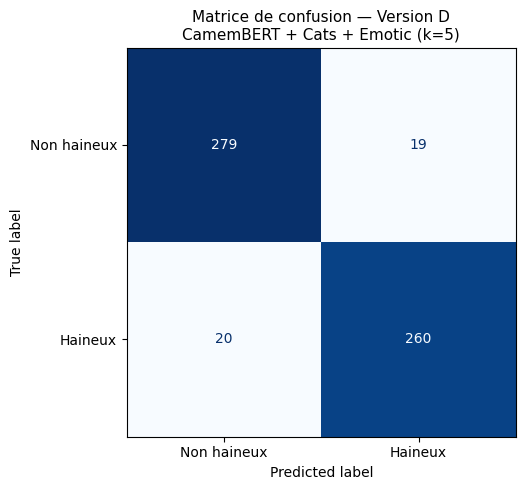

Calcul learning curve Version D en cours...


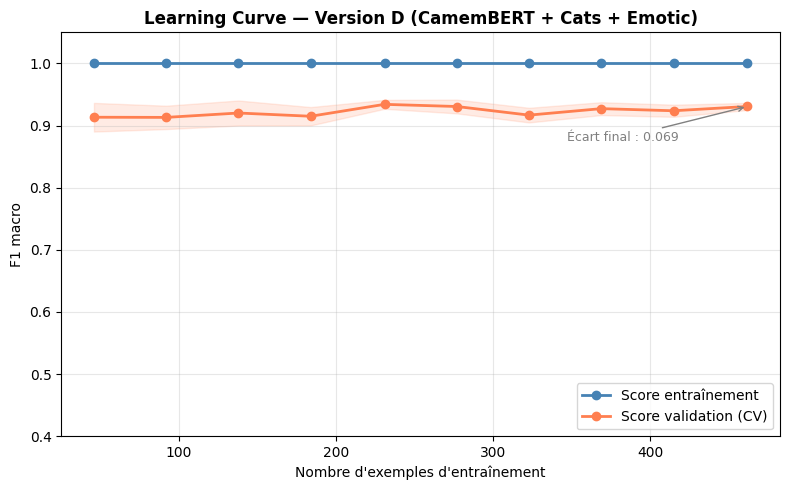


Version D — Score validation final : 0.9307 ± 0.0057
Version D — Écart train/val final  : 0.0693


In [ ]:

X_combined_D = np.hstack([X_embeddings_D, X_emotion_D])

print(f"X_embeddings_D : {X_embeddings_D.shape}")
print(f"X_emotion_D    : {X_emotion_D.shape}")
print(f"X_combined_D   : {X_combined_D.shape}")

cv_D = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_D = make_pipeline(
    StandardScaler(),
    LogisticRegression(C=1.0, max_iter=2000, solver='lbfgs', random_state=42)
)

y_pred_D = cross_val_predict(lr_D, X_combined_D, y_D, cv=cv_D)

print("\nRÉSULTATS — Version D (CamemBERT + Cats + Emotic) :")
print(f"  Accuracy  = {accuracy_score(y_D, y_pred_D):.4f}")
print(f"  Precision = {precision_score(y_D, y_pred_D, average='macro'):.4f}")
print(f"  Recall    = {recall_score(y_D, y_pred_D, average='macro'):.4f}")
print(f"  F1        = {f1_score(y_D, y_pred_D, average='macro'):.4f}")

print("\nRapport détaillé Version D :")
print(classification_report(y_D, y_pred_D, target_names=['Non haineux', 'Haineux']))




cm_D = confusion_matrix(y_D, y_pred_D)

fig_cm_D, ax_cm_D = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm_D, display_labels=['Non haineux', 'Haineux']).plot(
    ax=ax_cm_D, colorbar=False, cmap='Blues')
ax_cm_D.set_title(
    'Matrice de confusion — Version D\nCamemBERT + Cats + Emotic (k=5)',
    fontsize=11
)
plt.tight_layout()
plt.savefig('confusion_version_D.png', dpi=150, bbox_inches='tight')
plt.show()



cv_D_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_D_lc = make_pipeline(
    StandardScaler(),
    LogisticRegression(C=1.0, max_iter=2000, solver='lbfgs', random_state=42)
)

print("Calcul learning curve Version D en cours...")

train_sizes_D, train_scores_D, val_scores_D = learning_curve(
    lr_D_lc, X_combined_D, y_D,
    cv=cv_D_lc,
    scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_mean_D = train_scores_D.mean(axis=1)
train_std_D  = train_scores_D.std(axis=1)
val_mean_D   = val_scores_D.mean(axis=1)
val_std_D    = val_scores_D.std(axis=1)

fig_D, ax_D = plt.subplots(figsize=(8, 5))

ax_D.plot(train_sizes_D, train_mean_D, 'o-', color='steelblue',
          label='Score entraînement', linewidth=2)
ax_D.fill_between(train_sizes_D,
                  train_mean_D - train_std_D,
                  train_mean_D + train_std_D,
                  alpha=0.15, color='steelblue')

ax_D.plot(train_sizes_D, val_mean_D, 'o-', color='coral',
          label='Score validation (CV)', linewidth=2)
ax_D.fill_between(train_sizes_D,
                  val_mean_D - val_std_D,
                  val_mean_D + val_std_D,
                  alpha=0.15, color='coral')

gap_D = train_mean_D[-1] - val_mean_D[-1]
ax_D.annotate(f'Écart final : {gap_D:.3f}',
              xy=(train_sizes_D[-1], val_mean_D[-1]),
              xytext=(-130, -25),
              textcoords='offset points',
              fontsize=9,
              arrowprops=dict(arrowstyle='->', color='gray'),
              color='gray')

ax_D.set_title('Learning Curve — Version D (CamemBERT + Cats + Emotic)',
               fontsize=12, fontweight='bold')
ax_D.set_xlabel("Nombre d'exemples d'entraînement")
ax_D.set_ylabel('F1 macro')
ax_D.set_ylim(0.4, 1.05)
ax_D.legend(loc='lower right')
ax_D.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curve_version_D.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nVersion D — Score validation final : {val_mean_D[-1]:.4f} ± {val_std_D[-1]:.4f}")
print(f"Version D — Écart train/val final  : {gap_D:.4f}")

          Version  Accuracy  Precision   Recall  F1 (macro)
 A — Sans émotion  0.930796   0.930729 0.930729    0.930729
         B — Cats  0.934256   0.934435 0.933977    0.934161
       C — Emotic  0.932526   0.932505 0.932407    0.932453
D — Cats + Emotic  0.932526   0.932505 0.932407    0.932453


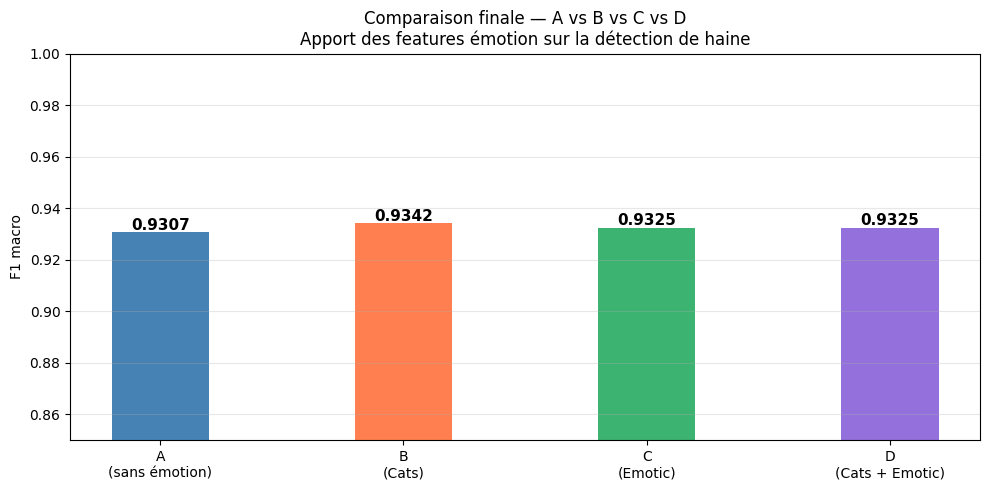

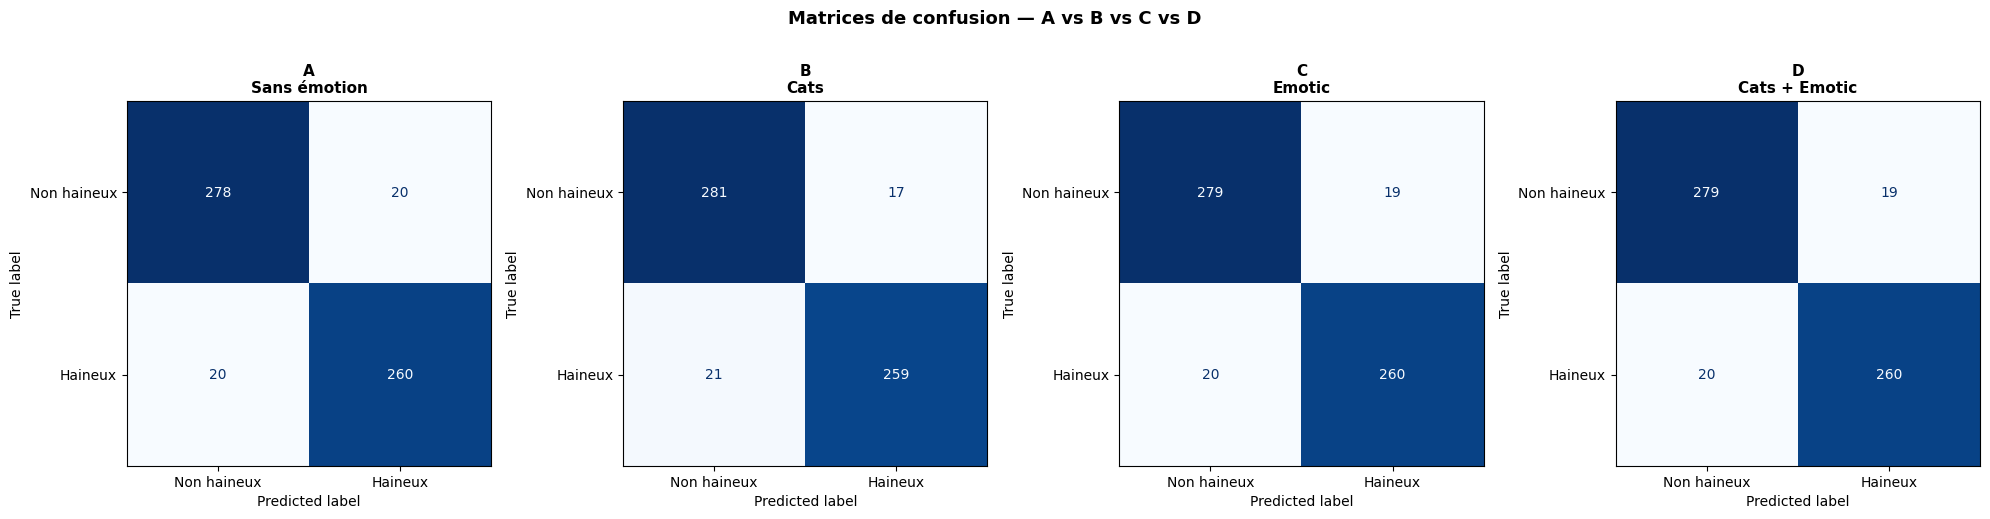

In [ ]:


results_final = {
    'Version': [
        'A — Sans émotion',
        'B — Cats',
        'C — Emotic',
        'D — Cats + Emotic'
    ],
    'Accuracy': [
        accuracy_score(y,   y_pred_A),
        accuracy_score(y,   y_pred_B),
        accuracy_score(y_C, y_pred_C),
        accuracy_score(y_D, y_pred_D)
    ],
    'Precision': [
        precision_score(y,   y_pred_A, average='macro'),
        precision_score(y,   y_pred_B, average='macro'),
        precision_score(y_C, y_pred_C, average='macro'),
        precision_score(y_D, y_pred_D, average='macro')
    ],
    'Recall': [
        recall_score(y,   y_pred_A, average='macro'),
        recall_score(y,   y_pred_B, average='macro'),
        recall_score(y_C, y_pred_C, average='macro'),
        recall_score(y_D, y_pred_D, average='macro')
    ],
    'F1 (macro)': [
        f1_score(y,   y_pred_A, average='macro'),
        f1_score(y,   y_pred_B, average='macro'),
        f1_score(y_C, y_pred_C, average='macro'),
        f1_score(y_D, y_pred_D, average='macro')
    ],
}

df_final = pd.DataFrame(results_final)
print(df_final.to_string(index=False))

# --- Bar chart F1 ---
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']
labels = ['A\n(sans émotion)', 'B\n(Cats)', 'C\n(Emotic)', 'D\n(Cats + Emotic)']
f1_values = df_final['F1 (macro)'].values

fig_final, ax_final = plt.subplots(figsize=(10, 5))
bars = ax_final.bar(labels, f1_values, color=colors, width=0.4)
ax_final.set_ylim(0.85, 1.0)
ax_final.set_ylabel('F1 macro')
ax_final.set_title('Comparaison finale — A vs B vs C vs D\nApport des features émotion sur la détection de haine')
for bar, v in zip(bars, f1_values):
    ax_final.text(bar.get_x() + bar.get_width() / 2,
                  v + 0.001, f'{v:.4f}',
                  ha='center', fontweight='bold', fontsize=11)
ax_final.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('comparaison_finale_A_B_C_D.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 4 matrices de confusion ---
fig_cms, axes_cms = plt.subplots(1, 4, figsize=(20, 5))
for ax, y_true, y_pred, title in zip(
    axes_cms,
    [y,       y,       y_C,      y_D],
    [y_pred_A, y_pred_B, y_pred_C, y_pred_D],
    ['A\nSans émotion', 'B\nCats', 'C\nEmotic', 'D\nCats + Emotic']
):
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Non haineux', 'Haineux']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=11, fontweight='bold')

plt.suptitle('Matrices de confusion — A vs B vs C vs D',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_A_B_C_D.png', dpi=150, bbox_inches='tight')
plt.show()

Le résultat le plus important : D = C

C et D sont strictement identiques (0.9325, 279/19/20/260). Combiner Cats + Emotic n'apporte rien de plus qu'Emotic seul. Cela signifie que quand Emotic est présent, il absorbe complètement l'information portée par Cats — les deux sources sont redondantes du point de vue du classifieur.

Classement final et interprétation :

**🥇 Version B (Cats)** — 0.9342
Meilleure version globale malgré le moins de features. Les catégories larges (colere, mepris, joie) sont directement alignées avec le vocabulaire du discours haineux. C'est la pertinence domaine qui prime.

**🥈 Version C et D (Emotic)** — 0.9325
Emotic apporte un gain réel mais moindre. Ses 15 dimensions sont plus génériques et moins discriminantes pour la haine spécifiquement. Et ajouter Cats par dessus (version D) ne change rien car Emotic couvre déjà ce que Cats apporte.

**🥉 Version A (baseline)** — 0.9307
Excellente baseline qui confirme la puissance de CamemBERT seul.

**Conclusion globale pour mémoire**

Trois enseignements majeurs ressortent de cette expérience :

1. L'émotion aide toujours, mais modestement. Quelle que soit la représentation (Cats, Emotic, ou les deux), le gain sur la baseline reste entre +0.18% et +0.35% de F1 macro. CamemBERT encode déjà implicitement l'émotion depuis le texte brut, ce qui plafonne naturellement l'apport de features émotionnelles explicites.

2. La qualité prime sur la quantité. Cats (8-10 catégories simples mais ciblées sur le discours haineux) bat Emotic (15 dimensions plus riches mais génériques). Cela valide le principe que des features adaptées au domaine sont plus efficaces que des features exhaustives mais génériques.

3. La combinaison ne garantit pas le gain. D = C prouve que deux sources émotionnelles peuvent être totalement redondantes. Emotic contient déjà l'information de Cats, ce qui rend leur union inutile. Dans un contexte de feature engineering, ajouter plus de features n'améliore pas nécessairement le modèle — voire peut le stabiliser sur un plateau.